# TS3
## Análisis de Fourier: FFT, desparramo, interpolación y ventaneo
#### Catalina Wynne

### Consigna:
En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.  

Luego, haremos el siguiente experimento:

Senoidal de frecuencia f0=k0∗fS/N=k0.Δf
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea k0
 

N/4
 
N/4+0.25
 
N/4+0.5
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  Δf
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

c) Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf
 de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.

Bonus
💎 Calcule la respuesta en frecuencia de los sistemas LTI de la TS2.

### Introducción 
En este trabajo analizaremos el fenómeno de desparramo espectral que ocurre al calcular la DFT de señales cuyas frecuencias no coinciden exactamente con los bins del espectro. 

Además,se utilizará la técnica de Zero Padding para mejorar la resolución visual del espectro sin modificar la informacion original de la señal.

### Definición de funciones y parámetros

In [2]:
import matplotlib.pyplot as plt
import numpy as np

#armo mi funcion  
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs #tiempo entre muestras
    tt = np.arange(0, nn) * ts #eje de tiempo 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

# Parámetros iniciales
vmax = np.sqrt(2) # Para que la potencia sea 1 W
dc = 0
ph = 0 
N = 1000 #cantidad de muestras total 
fs = N #frecuencia de muestreo 
df = fs/N #separacion de los puntos en mi graf de FFT


### Parte A: Efecto de desintonía 
Generamos tres señales con frecuencias levemente desplazadas respecto a un bin central
$k0 = N/4 = 250$


In [3]:
#cae en un bin 
ff1 = (N/4)*df
tt, xx1 = mi_funcion_sen(vmax, dc, ff1, ph, N, fs)
#corro la frecuencia +0.25
ff2 = ((N/4) + 0.25)*df
tt, xx2 = mi_funcion_sen(vmax, dc, ff2, ph, N, fs)
#corro la frec +0.5
ff3 = ((N/4) + 0.5)*df
tt, xx3 = mi_funcion_sen(vmax, dc, ff3, ph, N, fs)

# Eje de frecuencias
freqs = np.fft.fftfreq(N, 1/fs)
mitad = N // 2 #solo frec positivas 

# FFT y densidad espectral de potencia  de xx1
XX1 = np.fft.fft(xx1) #calculo la transformada 
XXmod_cuadrado = (np.abs(XX1) / N)**2  #potencia 
XXesp_db = 10 * np.log10(XXmod_cuadrado + 1e-12)  #paso a dB

# FFT y densidad espectral de potencia  de xx2
XX2 = np.fft.fft(xx2)
XXmod_cuadrado2 = (np.abs(XX2) / N)**2  
XXesp_db2 = 10 * np.log10(XXmod_cuadrado2 + 1e-12)  

# FFT y densidad espectral de potencia  de xx3
XX3 = np.fft.fft(xx3)
XXmod_cuadrado3 = (np.abs(XX3) / N)**2  
XXesp_db3 = 10 * np.log10(XXmod_cuadrado3 + 1e-12)

### Gráficos 

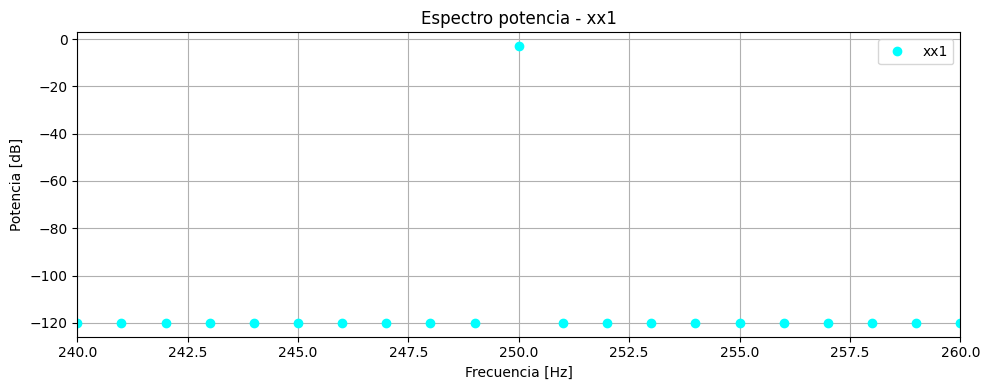

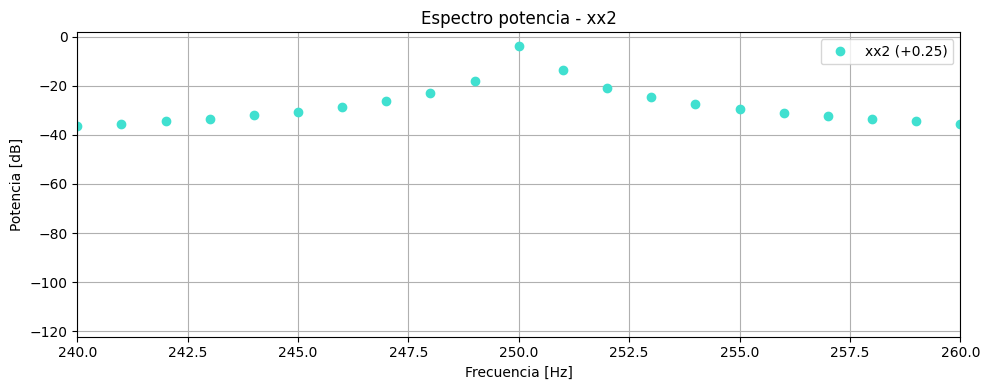

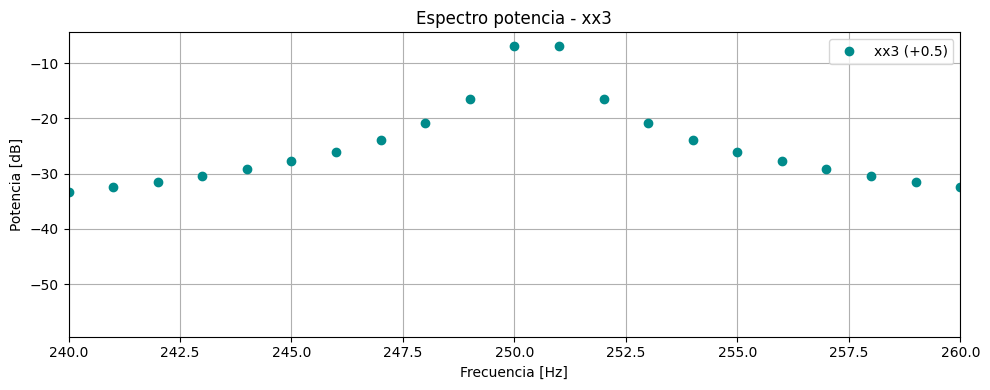

In [5]:
# Figura 1: xx1
plt.figure(1, figsize=(10, 4), dpi=100)
plt.plot(freqs[:mitad], XXesp_db[:mitad], color='aqua', marker='o', linestyle='none', label='xx1')
plt.title('Espectro potencia - xx1')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.xlim(240, 260) # Zoom para ver el detalle
plt.grid(True)
plt.legend()
plt.tight_layout()

# Figura 2: xx2
plt.figure(2, figsize=(10, 4), dpi=100)
plt.plot(freqs[:mitad], XXesp_db2[:mitad], color='turquoise', marker='o', linestyle='none', label='xx2 (+0.25)')
plt.title('Espectro potencia - xx2')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.xlim(240, 260)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Figura 3: xx3
plt.figure(3, figsize=(10, 4), dpi=100)
plt.plot(freqs[:mitad], XXesp_db3[:mitad], color='darkcyan', marker='o', linestyle='none', label='xx3 (+0.5)')
plt.title('Espectro potencia - xx3')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.xlim(240, 260)
plt.grid(True)
plt.legend()
plt.tight_layout()

Cuando la frecuencia de la señal coincide exactamente con un bin de la DFT, la energía se concentra en un único punto del espectro.

Al introducir una pequeña desintonía, la frecuencia deja de coincidir con los bins discretos y la energía se distribuye entre varios de ellos. Este fenómeno se conoce como desparramo espectral.

A medida que aumenta la desintonía: el pico se ensancha, aparecen lóbulos laterales y la energía se reparte en múltiples frecuencias. 

Esto ocurre porque la DFT proyecta la señal sobre un conjunto discreto de frecuencias.

### Pate B: Verificación de la potencia 

In [7]:
pot_tiempo_xx1 = np.var(xx1)
pot_frec_xx1 = np.sum(XXmod_cuadrado)

print(f"Potencia en el tiempo (xx1): {pot_tiempo_xx1:.4f} W")
print(f"Potencia en frecuencia (xx1): {pot_frec_xx1:.4f} W")

Potencia en el tiempo (xx1): 1.0000 W
Potencia en frecuencia (xx1): 1.0000 W


Se verifica que la potencia unitaria se mantiene en el tiempo como en la frecuencia, cumpliendo la identidad de Parseval.

Aunque dos señales difieran muy poco en frecuencia, su representación en la DFT puede ser muy distinta debido a que ésta sólo evalúa frecuencias discretas. Si la señal no coincide con esos valores, su energía se distribuye en todo el espectro.

### Parte C: Zero Padding

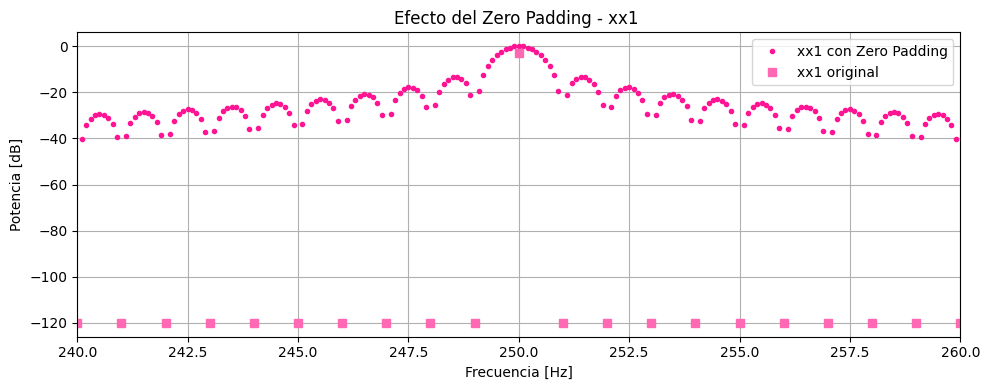

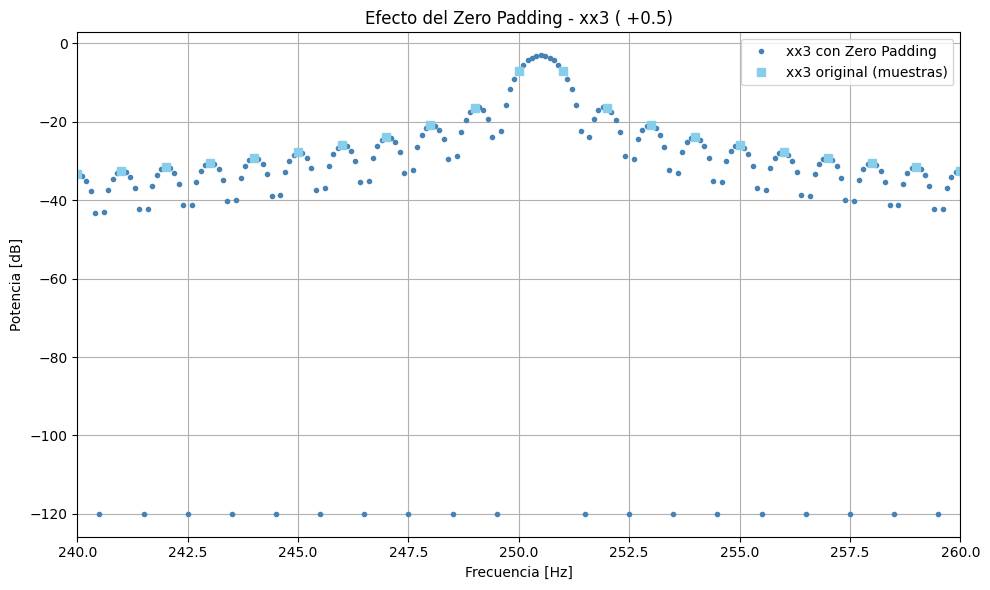

In [9]:
# --- PARTE C: Zero Padding ---
cant_zpadding = 8
#calcula la cantidad de ceros que le voy a agregar a mi señal original 
ceros_a_agregar = cant_zpadding * N + N
#agregamos los ceros
xx1_padded = np.pad(xx1, (0, ceros_a_agregar), 'constant')
xx2_padded = np.pad(xx2, (0, ceros_a_agregar), 'constant')
xx3_padded = np.pad(xx3, (0, ceros_a_agregar), 'constant')

N_pad = len(xx1_padded) 
freqs_pad = np.fft.fftfreq(N_pad, 1/fs) # Corrección del eje de frecuencias

#Nuevas FFT
XX1_pad = np.fft.fft(xx1_padded)
XX2_pad = np.fft.fft(xx2_padded)
XX3_pad = np.fft.fft(xx3_padded)

#Para XX1
XXmod_cuadrado1_pad = (np.abs(XX1_pad) / N)**2 
XXesp_db1_pad = 10 * np.log10(XXmod_cuadrado1_pad * 2 + 1e-12) 
#Para XX2
XXmod_cuadrado2_pad = (np.abs(XX2_pad) / N)**2 
XXesp_db2_pad = 10 * np.log10(XXmod_cuadrado2_pad * 2 + 1e-12)
#Para XX3
XXmod_cuadrado3_pad = (np.abs(XX3_pad) / N)**2 
XXesp_db3_pad = 10 * np.log10(XXmod_cuadrado3_pad + 1e-12) 

# Zero Padding graficos 
# Figura 4 : Efecto en xx1
plt.figure(4, figsize=(10, 4), dpi=100)
plt.plot(freqs_pad[:N_pad//2], XXesp_db1_pad[:N_pad//2], color='deeppink', marker='.', linestyle='none', label='xx1 con Zero Padding')
plt.plot(freqs[:mitad], XXesp_db[:mitad], color='hotpink', marker='s', linestyle='none', label='xx1 original')
plt.title('Efecto del Zero Padding - xx1 ')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.xlim(240, 260)
plt.grid(True)
plt.legend()
plt.tight_layout()

# Figura 6: Efecto en xx3
plt.figure(6, figsize=(10, 6), dpi=100)
plt.plot(freqs_pad[:N_pad//2], XXesp_db3_pad[:N_pad//2], color='steelblue', marker='.', linestyle='none', label='xx3 con Zero Padding')
plt.plot(freqs[:mitad], XXesp_db3[:mitad], color='skyblue', marker='s', linestyle='none', label='xx3 original (muestras)')
plt.title('Efecto del Zero Padding - xx3 ( +0.5)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.xlim(240, 260)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Al aplicar zero padding se observa una mayor densidad de puntos en el espectro, ya que aumenta la cantidad de puntos en la FFT, reduciendo el espacio entre bins. 

Esto produce un espectro más suave, mejora la visualización del desparramo. Sin embargo, no agrega información nueva y no mejora la resolución espectral real, tampoco reduce el desparramo.

El fenómeno observado se debe a la ventana rectangular implícita en la DFT.

### Conclusión

En este trabajo se analizó el desparramo espectral al calcular la DFT de señales desintonizadas respecto a los bins.

Se comprobó que variaciones pequeñas en la frecuencia producen grandes cambios en el espectro debido a la discretización en frecuencia.

Se verificó la conservación de la potencia mediante la identidad de Parseval y se estudió el efecto del zero padding, concluyendo que mejora la visualización del espectro pero no su resolución real.